# Compound Data Acquisition

Welcome to the practical course Molecular Modelling!

This course will focus on computational methods for modeling of molecules, and is based on your already gained expertise from the lectures. You will try different methods and data visualization techniques throughout this course, followed by final presentation at the end. As this course is a practical course, you will need extra research about your target, the methods you used ... 

If something is unclear, feel free to ask our tutor(s)!

In this notebook, we will learn more about the ChEMBL database and how to extract data from ChEMBL, i.e. (compound, activity data) pairs for a target of interest. These data sets can be used for many cheminformatics tasks, such as similarity search, clustering or machine learning.

Our work here will include finding compounds which were tested against a target and filtering available bioactivity data.

Goal: Get a list of compounds with bioactivity data for your target

## ChEMBL database

ChEMBL is a manually curated database of bioactive molecules with drug-like properties. It brings together chemical, bioactivity and genomic data to aid the translation of genomic information into effective new drugs. See https://www.ebi.ac.uk/chembl/ for more information.

Current data content (as of 12.2024, ChEMBL 35):

>2.4 million distinct compounds

>20.7 million activity values

>Assays are mapped to ~16,000 targets

**Data sources** include scientific literature, PubChem bioassays, Drugs for Neglected Diseases Initiative (DNDi), BindingDB database, …

ChEMBL data can be accessed via a web-interface [https://www.ebi.ac.uk/chembl/] (RESTful web service), the EBI-RDF platform [https://www.ncbi.nlm.nih.gov/pubmed/24413672] and the ChEMBL web rescource client [https://github.com/chembl/chembl_webresource_client] (Python client library for accessing ChEMBL data; handles interaction with the HTTPS protocol).

## Compound activity measures

How is the potency of a drug usually measured? 

Check the following literature and answer the questions: 


Literature:
1) https://en.wikipedia.org/wiki/IC50   
2) https://pubs.acs.org/doi/10.1021/acs.jmedchem.4c02052
3) https://pmc.ncbi.nlm.nih.gov/articles/PMC7357848/
4) https://pubmed.ncbi.nlm.nih.gov/32407356/

Questions: 
1) What does IC₅₀ represent in pharmacology?
2) How is IC₅₀ typically determined in an experiment?
3) Why the potency of a drug is usually measured by IC₅₀?"
4) What are the pros/cons of IC₅₀ as a potency metric?
5) What binding strength would you expect for a strong-binding drug?

## Excercise 1

As you might already know from the Hands-On session (part of lectures), we need certain packages and python libraries to run specific code.

Let's import packages we're going to use further:

In [1]:
%pip install chembl-webresource-client tqdm rdkit mols2grid

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/ParmEd-3.2.0-py2.7-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/pytraj-2.0.5-py2.7-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/pdb4amber-1.7.dev0-py2.7.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at h

Next, if you didn't already do it, create a directory where we want to store our generated data. 

Write python function `create_and_check_folder` to check if folder you want exist. If not - code need to create it.

In [2]:
import numpy as np
import pandas as pd
from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm
import os

In [3]:
def create_and_check_folder(datapath):
    if os.path.exists(datapath):
        return True
    else:
        return False
    

In [4]:

create_and_check_folder(datapath="/home/praktikum/storage/meinschad_lukas_ff_pr")

True

Next, let's create resource objects for API access.   
What is an API? Check https://en.wikipedia.org/wiki/API

More info and examples what you can get via ChEMBL API: 
- https://github.com/chembl/chembl_webresource_client 
- https://github.com/chembl/notebooks/blob/main/ChEMBL_webresource_client_examples.ipynb
- https://chembl.blogspot.com/2015/07/chembl-python-client-update.html

In [5]:
# Create client instances for different resource types
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

In [6]:
type(targets_api)

chembl_webresource_client.query_set.QuerySet

The `chembl_webresource_client.query_set.QuerySet` is a custom Python class provided by the ChEMBL web resource client. Its main purpose is to serve as a flexible querying interface to the ChEMBL REST API. That;s kind of a specialized container that encapsulates the logic for:
- Querying: It builds and manages API queries toward various endpoints (e.g., targets, molecules, assays, etc.).
- Filtering & Searching: It supports methods such as .search(), .filter(), and more, enabling you to narrow down results based on your query parameters.
- Lazy Evaluation and Pagination: Much like the QuerySet in Django’s ORM, it delays the actual API request until you iterate over or explicitly evaluate it. This approach optimizes performance and manages pagination automatically.

You essentially interact with it as if it were a dataset from which you can retrieve specific biological data from the ChEMBL repository.

Let's get data about out target (protein of interest).

We need Uniprot ID or ChEMBL ID to get information about our target of interest from ChEMBL DB.

In our case target of interest will be human EGFR kinase.

In [7]:
uniprot_id = "P27487"

Now let's fetch the target data from ChEMBL   
... if you couldn't get an uniprot id easily, you could apply the API's filter function here and search by protein name ('pref_name__iexact') like:

`targets = targets_api.filter(pref_name__iexact='Neuraminidase').only(**keep_data_dict)`

For more info and examples check: https://github.com/chembl/notebooks/blob/main/ChEMBL_webresource_client_examples.ipynb. 


In [8]:
# Get targets by uniprot id from ChEMBL but restrict it to specified values only: "target_chembl_id", "organism", "pref_name", "target_type"
targets_query = targets_api.get(target_components__accession=uniprot_id).only(
    "target_chembl_id", "organism", "pref_name", "target_type"
)

print(f'The type of the targets is "{type(targets_query)}"')
targets_query

The type of the targets is "<class 'chembl_webresource_client.query_set.QuerySet'>"


[{'organism': 'Homo sapiens', 'pref_name': 'Dipeptidyl peptidase IV', 'target_chembl_id': 'CHEMBL284', 'target_type': 'SINGLE PROTEIN'}, {'organism': 'Homo sapiens', 'pref_name': 'Dipeptidyl peptidase II and dipeptidyl peptidase IV (DPP2 and DPP4)', 'target_chembl_id': 'CHEMBL2111469', 'target_type': 'SELECTIVITY GROUP'}]

The results of the query are stored in targets, a `QuerySet`, i.e. results of a `QuerySet` aren’t fetched from the database until you “ask” for them. Internally, a `QuerySet` can be constructed, filtered, sliced, and generally passed around without actually hitting the database. That's like a database "footprint" that we can play around with before making "real" request. 

The client implements a Django QuerySet-like interface with lazy evaluation, which means it will only evaluate a request for data when a value is required. This approach reduces number of network requests and increases performance. The API also caches results locally for faster retrieval.


To get "real" target data, we need to download it from ChEMBL (we need to "ask" DB for it).


In [9]:
targets = pd.DataFrame.from_records(targets_query)
targets

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Dipeptidyl peptidase IV,CHEMBL284,SINGLE PROTEIN
1,Homo sapiens,Dipeptidyl peptidase IV,CHEMBL284,SINGLE PROTEIN
2,Homo sapiens,Dipeptidyl peptidase II and dipeptidyl peptida...,CHEMBL2111469,SELECTIVITY GROUP


After checking the entries, select your target of interest (target ChEMBL ID).

In [10]:
### TODO: Select first entry and save it to a new variable
target = targets.iloc[0]
print(target)

organism                       Homo sapiens
pref_name           Dipeptidyl peptidase IV
target_chembl_id                  CHEMBL284
target_type                  SINGLE PROTEIN
Name: 0, dtype: object


Great! You found your target. Now you should save it's chembl id in `chembl_id` variable:

In [11]:
chembl_id = target["target_chembl_id"]
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL284


### Get bioactivity data

Now, we want to fetch the bioactivity data for the target of interest.

In this step, we fetch the bioactivity data and filter it to only consider
- human proteins,
- bioactivity type IC50,
- exact measurements (relation '='),
- binding data (assay type 'B').

If you want to use multiple target IDs, try 'target_chembl_id__in' and provide a list of the ids.

For more info and examples check: https://github.com/chembl/notebooks/blob/main/ChEMBL_API_example_for_webinar.ipynb. 

In [12]:
# Filter bioactivities by target, activity type, relation, assay_type
bioactivities_filtered = bioactivities_api.filter(
    target_chembl_id=chembl_id, type="IC50", relation="=", activity_type="IC50", target="human proteins", assay_type="B"
).only(
    "activity_id",
    "assay_chembl_id",
    "assay_description",
    "assay_type",
    "molecule_chembl_id",
    "type",
    "standard_units",
    "relation",
    "standard_value",
    "target_chembl_id",
    "target_organism",
)

print(f"Length and type of bioactivities object: {len(bioactivities_filtered)}, {type(bioactivities_filtered)}")

bioactivities_filtered = pd.DataFrame.from_dict(bioactivities_filtered)
bioactivities_filtered.head

Length and type of bioactivities object: 4506, <class 'chembl_webresource_client.query_set.QuerySet'>


<bound method NDFrame.head of       activity_id assay_chembl_id  \
0          105501    CHEMBL666573   
1          106644    CHEMBL666573   
2          106647    CHEMBL666573   
3          108924    CHEMBL666573   
4          111620    CHEMBL666573   
...           ...             ...   
4501     25636166   CHEMBL5366934   
4502     25636167   CHEMBL5366934   
4503     25636168   CHEMBL5366934   
4504     25642824   CHEMBL5368774   
4505     25642825   CHEMBL5368774   

                                      assay_description assay_type  \
0     In vitro inhibition of human Dipeptidylpeptida...          B   
1     In vitro inhibition of human Dipeptidylpeptida...          B   
2     In vitro inhibition of human Dipeptidylpeptida...          B   
3     In vitro inhibition of human Dipeptidylpeptida...          B   
4     In vitro inhibition of human Dipeptidylpeptida...          B   
...                                                 ...        ...   
4501  Inhibition of human recombina

In our bioactivity set, each entry holds important information. 

Try to find out the molecule_chembl_id of your first entry of the set. What else is stored in the first entry? 

NB: You can check info without downloading entire dataset (it can be very time-consuming).

Now, let's download the bioactivity data from ChEMBL, similar as you did it for your target, and save in pandas dataframe `bioactivities_df`.

In [13]:
#bioactivities_df = bioactivities_api.filter(
#    molecule_chembl_id=molecule_chemblid_fe, ### add other filters here ###
#).only(
#    "activity_id",
#    "assay_chembl_id",
#    "assay_description",
#    "assay_type",
#    "molecule_chembl_id",
#    "type",
#    "standard_units",
#    "relation",
#    "standard_value",
#    "target_chembl_id",
#    "target_organism",
#)
#print(f"Length and type of bioactivities_df: {len(bioactivities_df)}, {type(bioactivities_df)}")

Check how bioactivity data looks like? Which columns has dataset? How many rows in it? Shape of the df?

In [14]:


rows = bioactivities_filtered.columns
print(rows)

# Diplay the shape of the df

# Number of columns
print("Number of Columns:" ,len(rows))
print("Number of Rows:", len(bioactivities_filtered))


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'relation', 'standard_units', 'standard_value',
       'target_chembl_id', 'target_organism', 'type', 'units', 'value'],
      dtype='object')
Number of Columns: 13
Number of Rows: 4506


Note that the first two rows describe the same bioactivity entry; we will remove such artifacts later during the deduplication step. 

Note also that we have columns for `standard_units/units` and `standard_values/values`; in the following, we will use the standardized columns (standardization by ChEMBL), and thus, we drop the other two columns.


In [15]:
print(bioactivities_filtered.iloc[0])
print(bioactivities_filtered.iloc[1])

activity_id                                                      105501
assay_chembl_id                                            CHEMBL666573
assay_description     In vitro inhibition of human Dipeptidylpeptida...
assay_type                                                            B
molecule_chembl_id                                          CHEMBL93558
relation                                                              =
standard_units                                                       nM
standard_value                                                 217000.0
target_chembl_id                                              CHEMBL284
target_organism                                            Homo sapiens
type                                                               IC50
units                                                                uM
value                                                             217.0
Name: 0, dtype: object
activity_id                              

So now drop the `units` and `value` column.

In [16]:
bioactivities_filtered = bioactivities_filtered.drop(["units","value"],axis="columns")



In [17]:
bioactivities_filtered.head

<bound method NDFrame.head of       activity_id assay_chembl_id  \
0          105501    CHEMBL666573   
1          106644    CHEMBL666573   
2          106647    CHEMBL666573   
3          108924    CHEMBL666573   
4          111620    CHEMBL666573   
...           ...             ...   
4501     25636166   CHEMBL5366934   
4502     25636167   CHEMBL5366934   
4503     25636168   CHEMBL5366934   
4504     25642824   CHEMBL5368774   
4505     25642825   CHEMBL5368774   

                                      assay_description assay_type  \
0     In vitro inhibition of human Dipeptidylpeptida...          B   
1     In vitro inhibition of human Dipeptidylpeptida...          B   
2     In vitro inhibition of human Dipeptidylpeptida...          B   
3     In vitro inhibition of human Dipeptidylpeptida...          B   
4     In vitro inhibition of human Dipeptidylpeptida...          B   
...                                                 ...        ...   
4501  Inhibition of human recombina

Now let's filter and preprocess our bioactivity data.

You need to do the following:

1. Convert `standard_value`’s datatype from `object` to `float` (in order to make these values usable in calculations later on)
2. Delete entries with missing values (because we can't use missed values in calculations)
3. Keep only entries with `standard_unit == nM` (because we only want to keep bioactivity entries in nM)
4. Find duplicate molecules (because sometimes the same molecule (`molecule_chembl_id`) has been tested more than once) and calculate the geometric mean of IC50 for them --> store as a single entry with this averaged IC50 value
5. Reset `DataFrame` index (since we deleted some rows and now want the index to be continuous)
6. Rename columns (from "standard_value" to "IC50", from "standard_units" to "units")

In [31]:

from scipy.stats  import gmean
# Step 1 Convert to float

bioactivities_filtered["standard_value"] = bioactivities_filtered["standard_value"].astype(float)

#Step 2 Delete Nan Entries

bioactivities_filtered.dropna(inplace=True)



#Step 3 Keep only Elements with nM

bioactivities_filtered.drop(bioactivities_filtered[bioactivities_filtered["standard_units"]!= "nM"].index, inplace=True)

# Step 4 Find Duplicates of column

duplicates = bioactivities_filtered[bioactivities_filtered.duplicated("molecule_chembl_id")]
grouped_duplicates = duplicates.groupby(["molecule_chembl_id"], as_index=False)
mean_values = grouped_duplicates["standard_value"].apply(gmean,axis=0)




# Drop Duplicates from original list

bioactivities_filtered_no_dups = bioactivities_filtered.drop_duplicates(subset=["molecule_chembl_id"],keep="first")

# Now replace the value with the meane



bioactivities_filtered_no_dups.set_index("molecule_chembl_id",inplace=True)
mean_values.set_index("molecule_chembl_id",inplace=True)

# Update values where molecule chembl id is the same

print(bioactivities_filtered_no_dups.columns)

bioactivities_filtered_no_dups["standard_value"].update(mean_values["standard_value"])

bioactivities_filtered_no_dups.reset_index(inplace=True)
bioactivities_filtered_no_dups["standard_value"]

0           7.071068
1          21.977261
2         421.746369
3          13.000000
4          13.000000
           ...      
374    190000.000000
375    213000.000000
376     17000.000000
377      1128.577862
378    172257.038337
Name: standard_value, Length: 379, dtype: float64
Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'relation', 'standard_units', 'standard_value', 'target_chembl_id',
       'target_organism', 'type'],
      dtype='object')


/tmp/ipykernel_14300/730155162.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bioactivities_filtered_no_dups["standard_value"].update(mean_values["standard_value"])
/tmp/ipykernel_14300/730155162.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bioactivities_filtered_no_dups["standard_value"].update(mean_values["standard_value"])


0       217000.000000
1        41000.000000
2        12971.337244
3       188000.000000
4       247000.000000
            ...      
3814        12.000000
3815         2.500000
3816         3.400000
3817         0.220000
3818      3500.000000
Name: standard_value, Length: 3819, dtype: float64

In [24]:
#5. Reset `DataFrame` index (since we deleted some rows and now want the index to be continuous)

bioactivities_filtered_no_dups.reset_index(inplace=True)
#6. Rename columns (from "standard_value" to "IC50", from "standard_units" to "units")
bioactivities_df = bioactivities_filtered_no_dups.rename(columns={"standard_value":"IC50", "standard_units":"units"})
print(bioactivities_df)

ValueError: cannot insert level_0, already exists

In [25]:
print(f"Congratulations! Now you have a set of {len(bioactivities_df)} molecule ids with respective IC50 values for our target protein.")

Congratulations! Now you have a set of 3819 molecule ids with respective IC50 values for our target protein.


### Get compound data

We have now a proper df containing all molecules that were tested against our target - EGFR in this case - with measured bioactivity data.
Now let's get the molecular structures of the molecules that are linked to the respective bioactivity ChEMBL IDs.

Let’s have a look at the compounds from ChEMBL which we have defined bioactivity data for: let's fetch compound ChEMBL IDs and related to them structures.

In [26]:
compounds_provider = compounds_api.filter(
    molecule_chembl_id__in=list(bioactivities_df["molecule_chembl_id"])
).only("molecule_chembl_id", "molecule_structures")

and now let's download them ...

Again, we want to export the `QuerySet` object into a `pandas.DataFrame`. 
Given the data volume, **this can take some time**, so feel free to go for a coffee.

For that reason, we will first obtain the list of records through tqdm, so we get a nice progress bar and some ETAs. ETAs stands for Estimated Time of Arrival. It is used to indicate the estimated time remaining for the operation to complete (how long until your task is complete). 

In [27]:
compounds = list(tqdm(compounds_provider))

  0%|          | 0/3819 [00:00<?, ?it/s]

Let's pass the list of compounds to the DataFrame `compounds_df`.

In [30]:
compounds_df = pd.DataFrame(compounds)
print(compounds_df)

     molecule_chembl_id                                molecule_structures
0              CHEMBL28  {'canonical_smiles': 'O=c1cc(-c2ccc(O)cc2)oc2c...
1          CHEMBL269277  {'canonical_smiles': 'C=C(C)[C@@H]1CC[C@]2(C(=...
2             CHEMBL430  {'canonical_smiles': 'CO/N=C1\CN(c2nc3c(cc2F)c...
3              CHEMBL44  {'canonical_smiles': 'O=c1c(-c2ccc(O)cc2)coc2c...
4              CHEMBL50  {'canonical_smiles': 'O=c1c(O)c(-c2ccc(O)c(O)c...
...                 ...                                                ...
3814      CHEMBL5432172  {'canonical_smiles': 'N#C[C@@H]1CCCN1C(=O)CNC1...
3815      CHEMBL5433150  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...
3816      CHEMBL5434074  {'canonical_smiles': 'N#Cc1ccc(F)cc1Cn1c(N2CCC...
3817      CHEMBL5435542  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...
3818      CHEMBL5435689  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...

[3819 rows x 2 columns]


Wow, you did it! But before looking at the structures of molecules, let's preprocess and filter received data:

1) Remove rows with missing molecule structure entry
2) Delete duplications (by `molecule_chembl_id`)
3) Get for each molecule only canonical SMILES from entire `molecule_structures` column and save in new `smiles` column

In [56]:
compounds_df = compounds_df.replace(" ", np.nan)
nan_values = compounds_df[compounds_df.isna().any(axis=1)]

# Drop the nan values

compounds_df = compounds_df.dropna()

# search for duplicates in molecule chembl_id



canonical_smiles_list = []

for idx, row in compounds_df.iterrows():
    can_smiles = row.values[1]["canonical_smiles"]
    canonical_smiles_list.append(can_smiles)


compounds_df["canonical_smiles"] = canonical_smiles_list


<bound method NDFrame.head of      molecule_chembl_id                                molecule_structures  \
0              CHEMBL28  {'canonical_smiles': 'O=c1cc(-c2ccc(O)cc2)oc2c...   
1          CHEMBL269277  {'canonical_smiles': 'C=C(C)[C@@H]1CC[C@]2(C(=...   
2             CHEMBL430  {'canonical_smiles': 'CO/N=C1\CN(c2nc3c(cc2F)c...   
3              CHEMBL44  {'canonical_smiles': 'O=c1c(-c2ccc(O)cc2)coc2c...   
4              CHEMBL50  {'canonical_smiles': 'O=c1c(O)c(-c2ccc(O)c(O)c...   
...                 ...                                                ...   
3814      CHEMBL5432172  {'canonical_smiles': 'N#C[C@@H]1CCCN1C(=O)CNC1...   
3815      CHEMBL5433150  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...   
3816      CHEMBL5434074  {'canonical_smiles': 'N#Cc1ccc(F)cc1Cn1c(N2CCC...   
3817      CHEMBL5435542  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...   
3818      CHEMBL5435689  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...   

                                 

So far, we have multiple different molecular structure representations as a dict in "molecule_structures" column. Remove redundunt data to keep only the canonical SMILES.

Hint: "molecule_structures" as dict --> "molecule_structures" as string.

Hint: first check which key in dict (dict = data structure that consist of `{ key: value }` pairs) is responsible for storing canonical SMILES representation

Sanity check: Remove all molecules without a canonical SMILES string.

In [59]:
compounds_df = compounds_df.dropna(subset=["canonical_smiles"])

print("Length of Canoncial Smiles List", len(compounds_df))
print("Length of Bioactivity", len(bioactivities_df))

print(compounds_df.head)

Length of Canoncial Smiles List 3815
Length of Bioactivity 3819
<bound method NDFrame.head of      molecule_chembl_id                                molecule_structures  \
0              CHEMBL28  {'canonical_smiles': 'O=c1cc(-c2ccc(O)cc2)oc2c...   
1          CHEMBL269277  {'canonical_smiles': 'C=C(C)[C@@H]1CC[C@]2(C(=...   
2             CHEMBL430  {'canonical_smiles': 'CO/N=C1\CN(c2nc3c(cc2F)c...   
3              CHEMBL44  {'canonical_smiles': 'O=c1c(-c2ccc(O)cc2)coc2c...   
4              CHEMBL50  {'canonical_smiles': 'O=c1c(O)c(-c2ccc(O)c(O)c...   
...                 ...                                                ...   
3814      CHEMBL5432172  {'canonical_smiles': 'N#C[C@@H]1CCCN1C(=O)CNC1...   
3815      CHEMBL5433150  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...   
3816      CHEMBL5434074  {'canonical_smiles': 'N#Cc1ccc(F)cc1Cn1c(N2CCC...   
3817      CHEMBL5435542  {'canonical_smiles': 'Nc1nc(NC2=NC(c3ccccc3)=C...   
3818      CHEMBL5435689  {'canonical_smiles': 'N

### Merge both datasets

Merge values of interest from `bioactivities_df` and `compounds_df` in an `output_df` based on the compounds’ ChEMBL IDs (`molecule_chembl_id`), keeping the following columns:

- ChEMBL IDs: molecule_chembl_id
- SMILES: smiles
- units: units
- IC50: IC50

In [71]:
output_df = pd.merge(bioactivities_df,compounds_df, on="molecule_chembl_id",how="inner")


# We now 

columns_keep = ["molecule_chembl_id","IC50","canonical_smiles","units"]

columns_remove = [column for column in output_df.columns if not column in columns_keep]

output_df = output_df.drop(columns_remove,axis=1)
print(output_df.head)


<bound method NDFrame.head of      molecule_chembl_id units           IC50  \
0           CHEMBL93558    nM  217000.000000   
1          CHEMBL443622    nM   41000.000000   
2          CHEMBL403882    nM   12971.337244   
3          CHEMBL328795    nM  188000.000000   
4           CHEMBL97674    nM  247000.000000   
...                 ...   ...            ...   
3810      CHEMBL4297435    nM      12.000000   
3811      CHEMBL5418259    nM       2.500000   
3812      CHEMBL5430453    nM       3.400000   
3813      CHEMBL5434074    nM       0.220000   
3814      CHEMBL5425473    nM    3500.000000   

                                       canonical_smiles  
0                       N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  
1                                 C[C@H](N)C(=O)N1CCCC1  
2                              O=C([C@@H]1CCCN1)N1CCCC1  
3                               NC(=O)CC(N)C(=O)N1CCCC1  
4                                NCCCCC(N)C(=O)N1CCCCC1  
...                                          

### Add pIC50 values

Before the practical part, you have read the literature and answered the questions. therefore, you will be able to complete the next task without difficulty.

Your next tasks is:
- convert the IC50 values to pIC50 in a separate column `pIC50`

In [124]:

import numpy as np
def convert_ic50_to_pic50(ic50):
    """ 
    Converts IC 50 value to pIC50
    pIC_50 = -log_10(IC50)
    """
    return -np.log10(ic50*10e-9)



In [125]:
## TODO: Use your function to add a pIC50 column to your DataFrame

output_df["pIC50"] = output_df["IC50"].map(convert_ic50_to_pic50)

print(output_df["pIC50"])

0       2.663540
1       3.387216
2       3.887015
3       2.725842
4       2.607303
          ...   
3810    6.920819
3811    7.602060
3812    7.468521
3813    8.657577
3814    4.455932
Name: pIC50, Length: 3815, dtype: float64


**Question to answer**: 
- What is the difference in using IC₅₀ and pIC₅₀ for interpreting ingibitor potency? 

> Higher values of pIC50 indicate exponentially more potent inhibitor. pIC50 is usually given in terms of molar concentration (mol/L or M) thus requiring IC50 in units of M


- Which units are applicable for each of them? 
- How can you evaluate high/low IC₅₀ and high/low pIC₅₀ value? Why? 
- Which values are more appropriate to use for QSAR models and comparisons? Why?

## Visualisazion

Let’s have a look at the distribution of our collected data set's potency as ingibitor. To evaluate results easily we need proper visualization technic for it.

Which value it would be better to use for plotting (histogram)? Why?

Hint: you can use for plotting even built-in methods from `pandas` lib. You can learn more about it from: 
- https://mode.com/example-gallery/python_histogram
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.hist.html.

In [126]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/ParmEd-3.2.0-py2.7-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/pytraj-2.0.5-py2.7-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /media/TC_Lehre/program/amber18tools19/lib/python2.7/site-packages/pdb4amber-1.7.dev0-py2.7.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at h

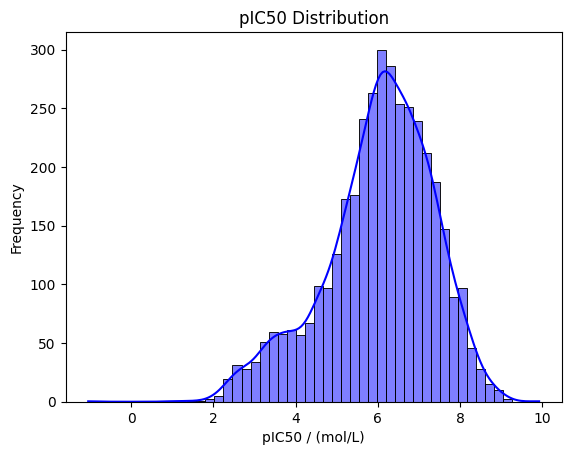

In [127]:
##TODO: Visualize potency distribution

import matplotlib.pyplot as plt
import seaborn as sns



sns.histplot(output_df["pIC50"],color="blue",kde=True,edgecolor="black",bins=50)
plt.xlabel("pIC50 / (mol/L)")
plt.ylabel("Frequency")
plt.title("pIC50 Distribution")

plt.show()



Higher Values of $pIC_{50}$ indicate exponentially more potent inhibitors!!

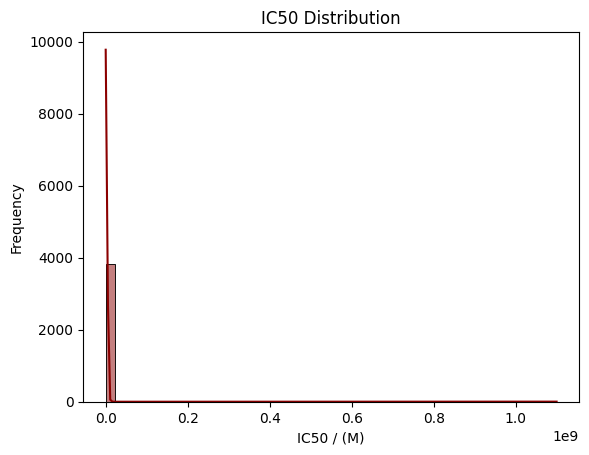

In [138]:
sns.histplot(output_df["IC50"],color="darkred",kde=True,edgecolor="black", bins=50)
plt.xlabel("IC50 / (M)")
plt.ylabel("Frequency")
plt.title("IC50 Distribution")
plt.show()

**Question**: Which conclusions you can make based on this plot?

In the next steps, let's add a column for RDKit molecule objects to our `DataFrame` and look at the structures of the molecules with the highest potency values.

In [139]:
## TODO: Add molecule column 'Mol', PandasTools is your friend but not the only possible solution (check rdkit.Chem documentation)
import rdkit
from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(output_df,smilesCol="canonical_smiles",molCol="mols")

print(output_df["mols"]) #nice


0       <rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>
1       <rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>
2       <rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>
3       <rdkit.Chem.rdchem.Mol object at 0x7f870fd61c40>
4       <rdkit.Chem.rdchem.Mol object at 0x7f870fd613f0>
                              ...                       
3810    <rdkit.Chem.rdchem.Mol object at 0x7f870f996420>
3811    <rdkit.Chem.rdchem.Mol object at 0x7f870f996490>
3812    <rdkit.Chem.rdchem.Mol object at 0x7f870f996500>
3813    <rdkit.Chem.rdchem.Mol object at 0x7f870f996570>
3814    <rdkit.Chem.rdchem.Mol object at 0x7f870f9965e0>
Name: mols, Length: 3815, dtype: object


In [145]:
## TODO: Sort molecules by potency, clean up the DataFrame

output_df.sort_values(by="pIC50",ascending=False)


,molecule_chembl_id,units,IC50,canonical_smiles,pIC50,mols
1168,CHEMBL237119,nM,1.200000e-02,CN(C)C(=O)[C@@H](c1ccc(-c2ccc(F)cc2)cc1)[C@H](...,9.920819,<rdkit.Chem.rdchem.Mol object at 0x7f870f94d620>
1171,CHEMBL237336,nM,6.400000e-02,C[C@@H](c1ccc(-c2ccc(F)cc2)cc1)[C@H](N)C(=O)N1...,9.193820,<rdkit.Chem.rdchem.Mol object at 0x7f870f94d770>
3694,CHEMBL5269668,nM,9.000000e-02,CC#CCN1C(N2CCC[C@@H](N)C2)=NC2C1C(=O)N(Cc1cccn...,9.045757,<rdkit.Chem.rdchem.Mol object at 0x7f870f9930d0>
2420,CHEMBL34062,nM,1.000000e-01,COc1cc(OC)cc(-c2nc(N)c(CN)c(-c3ccc(Cl)cc3Cl)n2)c1,9.000000,<rdkit.Chem.rdchem.Mol object at 0x7f870f96fe60>
3504,CHEMBL4448186,nM,1.000000e-01,CC#CCn1c(N2CCC[C@@H](N)C2)nc2c1c(=O)n(Cc1ccc(C...,9.000000,<rdkit.Chem.rdchem.Mol object at 0x7f870f98dd20>
...,...,...,...,...,...,...
344,CHEMBL175260,nM,1.000000e+06,O=C(CNCc1ccccc1)N1CCCC1,2.000000,<rdkit.Chem.rdchem.Mol object at 0x7f870f936a40>
45,CHEMBL268012,nM,1.800000e+06,Cl.O=C(C1CCCN1)N1CCCC1P(=O)(OCC(Cl)(Cl)Cl)OCC(...,1.744727,<rdkit.Chem.rdchem.Mol object at 0x7f870fd62490>
3497,CHEMBL4535549,nM,3.830000e+06,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,1.416801,<rdkit.Chem.rdchem.Mol object at 0x7f870f98da10>
35,CHEMBL276884,nM,9.100000e+06,Cl.O=C(C1CCCN1)N1CCCC1P(=O)(OCC(F)(F)F)OCC(F)(F)F,1.040959,<rdkit.Chem.rdchem.Mol object at 0x7f870fd61fc0>


In [157]:
## TODO: illustrate the 5 most active compounds

from rdkit.Chem import Draw

# get five most active compounds
output_df_sorted_descending = output_df.sort_values(by="pIC50",ascending=False)
mols_list = output_df_sorted_descending["mols"].head(5)

img =Draw.MolsToGridImage(mols_list,molsPerRow=5,subImgSize=(600,600))
print(type(img))
img.save("most_active_5_compounds.png")


<class 'PIL.PngImagePlugin.PngImageFile'>


In [161]:
## TODO: illustrate the 5 least active compounds

output_df_sorted_ascending = output_df.sort_values(by="pIC50",ascending=True)
mols_list = output_df_sorted_ascending["mols"].head(5)

img = Draw.MolsToGridImage(mols_list,molsPerRow=5,subImgSize=(600,600))
img.save("least_active_5_compounds.png")

### Write output data to file

You'll need received bioactivity-compound dataset in the following tasks, thus you need to save the data as `csv` file. 

**Note** that it is advisable to drop the 'Mol' column (which only contains an image of the molecules) when saving the data.

In [159]:
## TODO: drop column with visualized molecule

output_df.drop("mols",axis=1)

,molecule_chembl_id,units,IC50,canonical_smiles,pIC50
0,CHEMBL93558,nM,217000.000000,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,2.663540
1,CHEMBL443622,nM,41000.000000,C[C@H](N)C(=O)N1CCCC1,3.387216
2,CHEMBL403882,nM,12971.337244,O=C([C@@H]1CCCN1)N1CCCC1,3.887015
3,CHEMBL328795,nM,188000.000000,NC(=O)CC(N)C(=O)N1CCCC1,2.725842
4,CHEMBL97674,nM,247000.000000,NCCCCC(N)C(=O)N1CCCCC1,2.607303
...,...,...,...,...,...
3810,CHEMBL4297435,nM,12.000000,COC(=O)c1nc(C(F)(F)F)n2c1CN(C(=O)C[C@H](N)Cc1c...,6.920819
3811,CHEMBL5418259,nM,2.500000,N[C@H]1C[C@@H](N2Cc3nn4c(C(F)(F)F)cc(C(F)(F)F)...,7.602060
3812,CHEMBL5430453,nM,3.400000,Cc1ccc2c(c1)CN(C(=O)CC(C)(C)NCC(=O)N1CCC[C@H]1...,7.468521
3813,CHEMBL5434074,nM,0.220000,N#Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2cc(-c3c...,8.657577


In [160]:
## TODO: Save your data to a csv file

output_df.to_csv("bioactivity_and_smiles.csv",sep="\t")

**Result of your today's work PART 1**: you've collected bioactivity data for the target of interest from the ChEMBL database, filtered the data set in order to only contain molecules with measured IC50 bioactivity values, visualised molecules, etc.

Let's go to the next steps ...